In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv("housing.csv")

In [7]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
data.dropna(inplace = True)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [11]:
from sklearn.model_selection import train_test_split

x = data.drop(['median_house_value'], axis= 1)
y = data['median_house_value']

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)

In [13]:
train_data = x_train.join(y_train)

In [14]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
10091,-117.97,33.93,33.0,1700.0,369.0,981.0,362.0,4.5461,<1H OCEAN,194000.0
19635,-120.96,37.54,29.0,1468.0,245.0,747.0,231.0,3.4643,INLAND,125000.0
57,-122.28,37.82,52.0,1489.0,335.0,728.0,244.0,0.8172,NEAR BAY,85300.0
3698,-118.38,34.21,38.0,1363.0,395.0,1798.0,405.0,2.3182,<1H OCEAN,171200.0
15293,-117.28,33.10,13.0,2644.0,422.0,1197.0,399.0,6.5338,NEAR OCEAN,267900.0
...,...,...,...,...,...,...,...,...,...,...
4376,-118.28,34.10,49.0,2843.0,880.0,2004.0,796.0,2.7875,<1H OCEAN,217300.0
2287,-119.74,36.79,28.0,2857.0,619.0,1614.0,592.0,2.1573,INLAND,71400.0
7996,-118.15,33.86,32.0,2630.0,559.0,1069.0,491.0,2.4659,<1H OCEAN,209000.0
15832,-122.43,37.75,52.0,2285.0,509.0,839.0,456.0,4.7946,NEAR BAY,355600.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

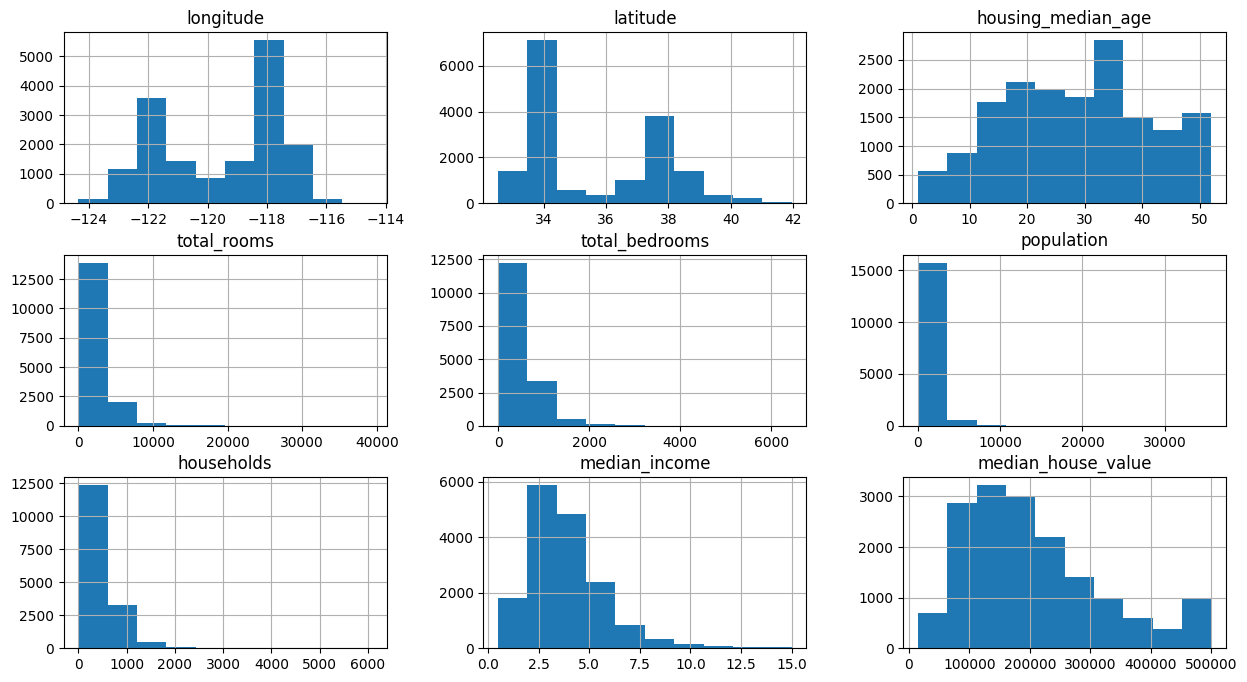

In [15]:
train_data.hist(figsize = (15,8))

<Axes: >

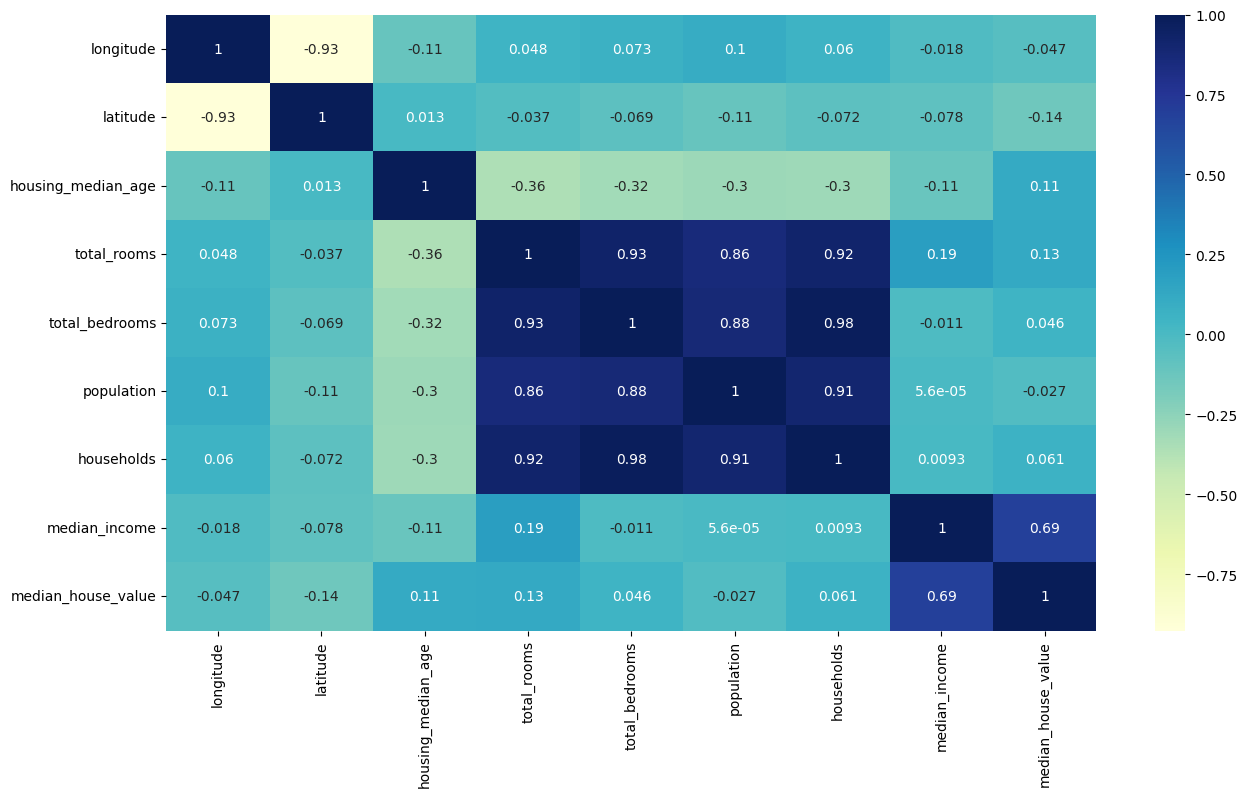

In [16]:
num = train_data.select_dtypes(include='number')
plt.figure(figsize=(15,8))
sns.heatmap(num.corr(), annot=True, cmap="YlGnBu")

In [17]:
train_data["total_rooms"] = np.log (train_data["total_rooms"] + 1)
train_data["total_bedrooms"] = np.log (train_data["total_bedrooms"] + 1)
train_data["population"] = np.log (train_data["population"] + 1)
train_data["households"] = np.log (train_data["households"] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

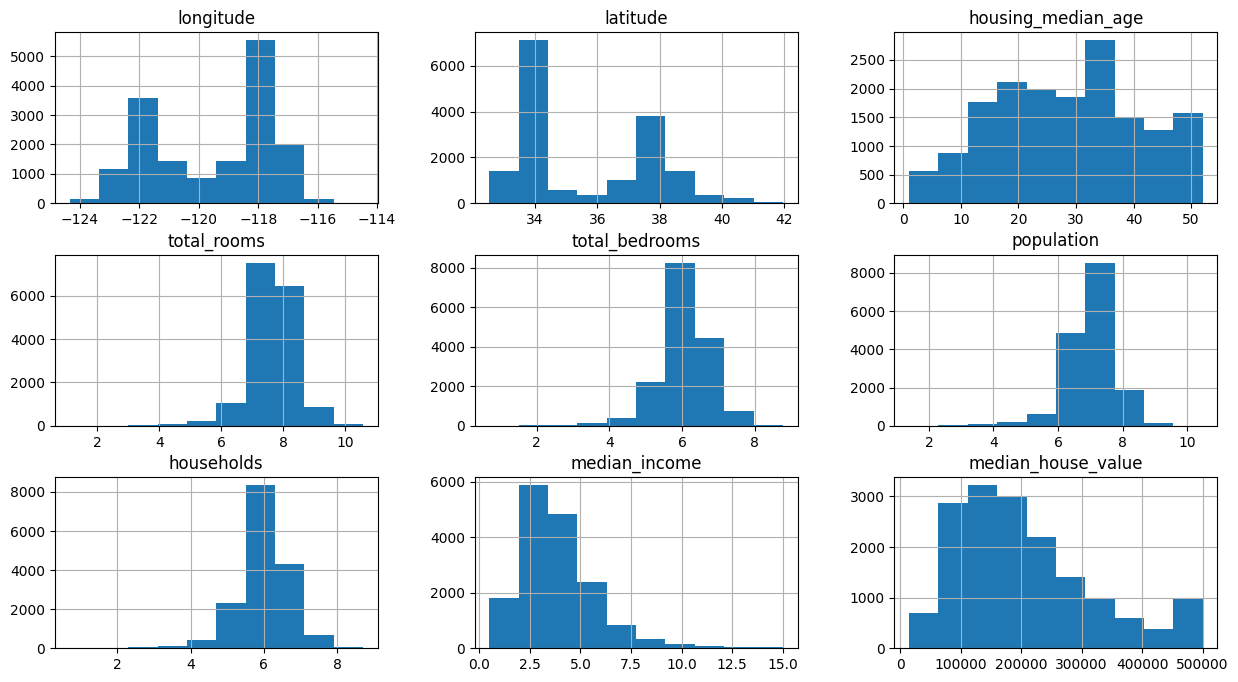

In [18]:
train_data.hist(figsize = (15,8))

In [19]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7194
INLAND        5224
NEAR OCEAN    2089
NEAR BAY      1836
ISLAND           3
Name: count, dtype: int64

In [20]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity , dtype=int)).drop(["ocean_proximity"], axis = 1)

In [21]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
10091,-117.97,33.93,33.0,7.438972,5.913503,6.889591,5.894403,4.5461,194000.0,1,0,0,0,0
19635,-120.96,37.54,29.0,7.292337,5.505332,6.617403,5.446737,3.4643,125000.0,0,1,0,0,0
57,-122.28,37.82,52.0,7.306531,5.817111,6.591674,5.501258,0.8172,85300.0,0,0,0,1,0
3698,-118.38,34.21,38.0,7.218177,5.981414,7.494986,6.006353,2.3182,171200.0,1,0,0,0,0
15293,-117.28,33.10,13.0,7.880426,6.047372,7.088409,5.991465,6.5338,267900.0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,-118.28,34.10,49.0,7.952967,6.781058,7.603399,6.680855,2.7875,217300.0,1,0,0,0,0
2287,-119.74,36.79,28.0,7.957877,6.429719,7.387090,6.385194,2.1573,71400.0,0,1,0,0,0
7996,-118.15,33.86,32.0,7.875119,6.327937,6.975414,6.198479,2.4659,209000.0,1,0,0,0,0
15832,-122.43,37.75,52.0,7.734559,6.234411,6.733402,6.124683,4.7946,355600.0,0,0,0,1,0


<Axes: >

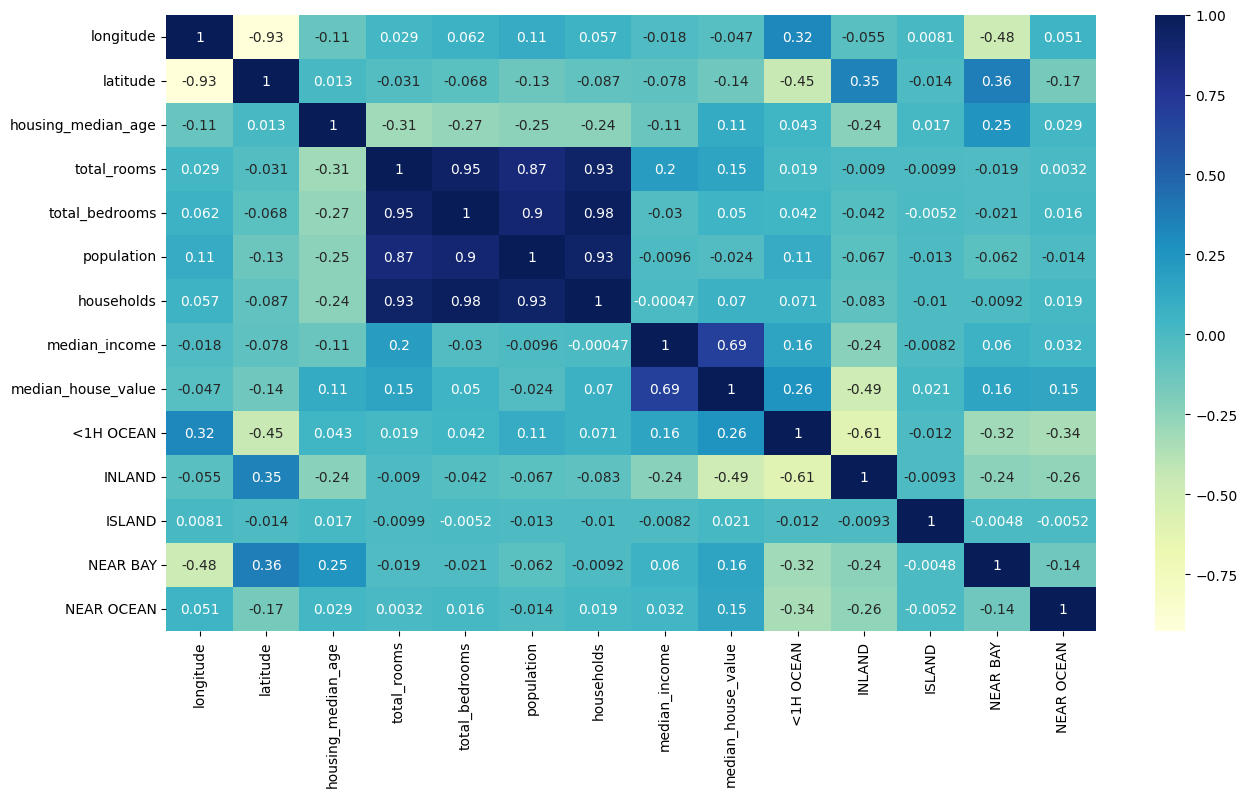

In [22]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

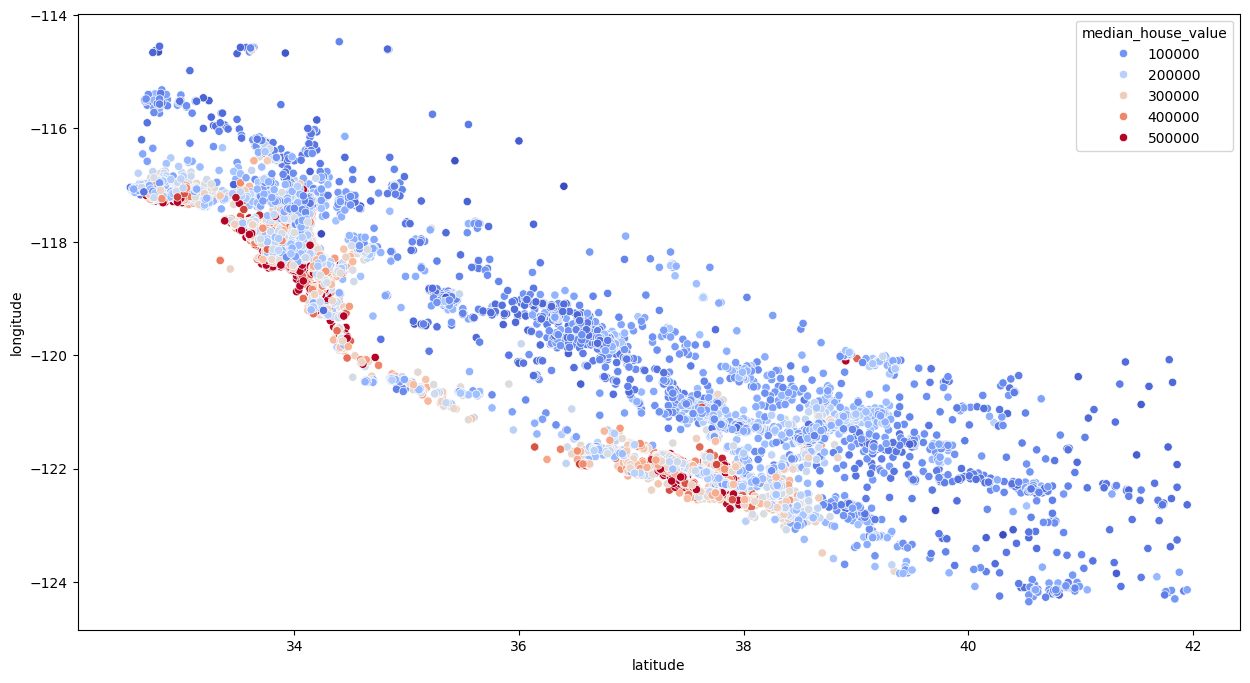

In [23]:
plt.figure(figsize = (15,8))
sns.scatterplot (x = "latitude", y = "longitude" ,data = train_data, hue = "median_house_value", palette = "coolwarm")

In [24]:
train_data["bedroom_ratio"] = train_data["total_bedrooms"] / train_data["total_rooms"]

In [25]:
train_data["household_rooms"] = train_data["total_rooms"] / train_data["households"]

<Axes: >

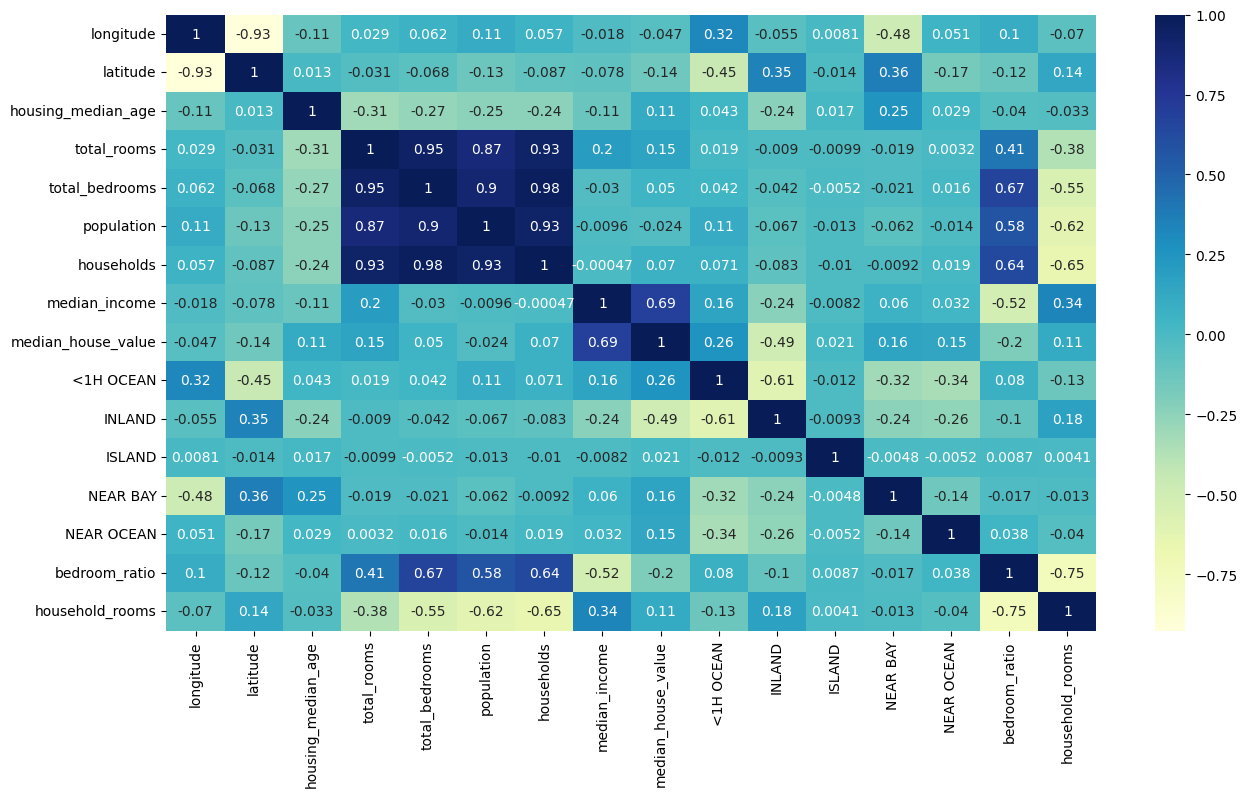

In [26]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train, y_train = train_data.drop(["median_house_value"] , axis = 1),train_data["median_house_value"]
x_train_s = scaler.fit_transform(x_train)

reg = LinearRegression()

reg.fit(x_train_s, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
test_data = x_test.join(y_test)

test_data["total_rooms"] = np.log (test_data["total_rooms"] + 1)
test_data["total_bedrooms"] = np.log (test_data["total_bedrooms"] + 1)
test_data["population"] = np.log (test_data["population"] + 1)
test_data["households"] = np.log (test_data["households"] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity , dtype=int)).drop(["ocean_proximity"], axis = 1)

test_data["bedroom_ratio"] = test_data["total_bedrooms"] / test_data["total_rooms"]
test_data["household_rooms"] = test_data["total_rooms"] / test_data["households"]



In [29]:
x_test, y_test = test_data.drop(["median_house_value"] , axis = 1),test_data["median_house_value"]

In [30]:
x_test_s = scaler.transform(x_test)

In [31]:
reg.score(x_test_s, y_test)

0.6694370888295232

In [32]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(x_train_s, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
forest.score(x_test_s, y_test)

0.8155736182541607

In [34]:
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()

param_grid = {
    "n_estimators": [3,10,30],
    "max_features": [2,4,6,8]
}

grid_search = GridSearchCV(forest, param_grid, cv=5,
                          scoring="neg_mean_squared_error",
                          return_train_score=True)

grid_search.fit(x_train_s, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


In [35]:

forest = RandomForestRegressor()

param_grid = {
    "n_estimators": [100,200,300],
    "min_samples_split":[2,4],
    "max_depth": [None,4,8]
}

grid_search = GridSearchCV(forest, param_grid, cv=5,
                          scoring="neg_mean_squared_error",
                          return_train_score=True)

grid_search.fit(x_train_s, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 4, ...], 'min_samples_split': [2, 4], 'n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [39]:
grid_search.best_estimator_.score(x_test_s,y_test)

0.8186246838332123